Links:
https://browse.library.kiwix.org/content/stackoverflow.com_en_all_2023-11/questions/24341114/simple-illumination-correction-in-images-opencv-c
https://pyimagesearch.com/2021/02/01/opencv-histogram-equalization-and-adaptive-histogram-equalization-clahe/
https://stackoverflow.com/questions/25008458/how-to-apply-clahe-on-rgb-color-images
https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet/preprocess_input
https://pypi.org/project/v-pyiqa/
https://docs.pytorch.org/docs/stable/generated/torch.no_grad.html

In [ ]:
# Section 1: Import Libraries
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score
import cv2
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.resnet50 import preprocess_input
import pyiqa
import torch


# Set random seeds for reproducibility
np.random.seed(25)
tf.random.set_seed(25)

print("Libraries imported!")


Libraries imported!


In [ ]:
# Section 2: Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

CLASS_NAMES = ['Bicycle', 'Boat', 'Bottle', 'Bus', 'Car', 'Cat', 
               'Chair', 'Cup', 'Dog', 'Motorbike', 'People', 'Table']
NUM_CLASSES = len(CLASS_NAMES)

# Paths
DATA_PATH = "C:/Users/marti/Desktop/College/Master Data Analytics/MachineLearning/CA_3/ExDark"
ENHANCED_PATH = "C:/Users/marti/Desktop/College/Master Data Analytics/MachineLearning/CA_3/ExDark_Enhanced"
os.makedirs(ENHANCED_PATH, exist_ok=True)

OUTPUT_PATH = "results"
os.makedirs(OUTPUT_PATH, exist_ok=True)
# Check if GPU is available, use GPU (cuda) if yes, otherwise use CPU
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
# Create BRISQUE metric
brisque = pyiqa.create_metric('brisque', device=device)
# Create NIQE metric
niqe = pyiqa.create_metric('niqe', device=device)

print({device})

{device(type='cpu')}


In [ ]:
# Section 3: HE Enhancement
# Create directory path for HE enhanced images
he_path = os.path.join(ENHANCED_PATH, 'HE')
# Loop through each class folder
for class_name in CLASS_NAMES:
    inp = os.path.join(DATA_PATH, class_name)# Input path: original images for this class
    out = os.path.join(he_path, class_name)# Output path: HE enhanced images for this class
    os.makedirs(out, exist_ok=True)# Create output directory if it doesn't exist
     # Loop through each file in the input folder
    for f in os.listdir(inp):
        if f.endswith(('.png','.jpg','.jpeg')):# Check if file is an image
            img = cv2.imread(os.path.join(inp, f))# Read image
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)# Convert BGR to RGB
            yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)# Convert RGB to YUV color space
            yuv[:,:,0] = cv2.equalizeHist(yuv[:,:,0])  # Apply histogram equalization only to Y (brightness) channel
            img = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB) # Convert back to RGB
            img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)# Convert back to BGR for saving
            cv2.imwrite(os.path.join(out, f), img)# Save the enhanced image

print("HE done")

# Section 4: CLAHE Enhancement

clahe_path = os.path.join(ENHANCED_PATH, 'CLAHE')

for class_name in CLASS_NAMES:
    inp = os.path.join(DATA_PATH, class_name)
    out = os.path.join(clahe_path, class_name)
    os.makedirs(out, exist_ok=True)
    
    for f in os.listdir(inp):
        if f.endswith(('.png','.jpg','.jpeg')):
            img = cv2.imread(os.path.join(inp, f))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)# Convert RGB to LAB color space
            clahe = cv2.createCLAHE(2.0, (8,8))# Create CLAHE object (clip limit=2.0, grid size=8x8)
            lab[:,:,0] = clahe.apply(lab[:,:,0])# Apply CLAHE only to L channel
            img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
            img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            cv2.imwrite(os.path.join(out, f), img)

print("CLAHE done")

HE done
CLAHE done


In [4]:
# Section 5: Create ResNet50 Model

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add classification head (changing from 1000 to 12 classes)
x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

# Create full model
model = Model(inputs=base_model.input, outputs=predictions)

# Freeze pre-trained layers
base_model.trainable = False

# Compile
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,612,300 (90.07 MB)

 Trainable params: 24,588 (96.05 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Load all images
# Create empty lists to store image paths and their labels
all_images = []
all_labels = []
# Loop through each class
for class_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(DATA_PATH, class_name)
    if os.path.exists(class_dir):
        for img_file in os.listdir(class_dir):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                all_images.append(os.path.join(class_dir, img_file))# Add full image path to list
                all_labels.append(class_idx)# Add corresponding class index to labels list

print(f"Original dataset: {len(all_images)} images")

# Split parameters
test_ratio = 0.20
validation_ratio = 0.10
train_ratio = 0.70

# First split: train+val (90%) and test (10%)
X_train_val, X_test_orig, y_train_val, y_test_orig = train_test_split(
    all_images, all_labels, 
    test_size=test_ratio, 
    stratify=all_labels, 
    random_state=25
)

# Second split: train (70%) and val (20%) from train+val
val_size = validation_ratio / (train_ratio + validation_ratio)  # 0.10 / 0.80 = 0.125
X_train_orig, X_val_orig, y_train_orig, y_val_orig = train_test_split(
    X_train_val, y_train_val, 
    test_size=val_size, 
    stratify=y_train_val, 
    random_state=25
)
# Assign to more readable variable names
train_images_orig = X_train_orig
train_labels_orig = y_train_orig
test_images_orig = X_test_orig
test_labels_orig = y_test_orig
val_images_orig = X_val_orig
val_labels_orig = y_val_orig
# Print split statistics
print(f"Train: {len(train_images_orig)} ({len(train_images_orig)/len(all_images)*100:.1f}%)")
print(f"Test: {len(test_images_orig)} ({len(test_images_orig)/len(all_images)*100:.1f}%)")
print(f"Val: {len(val_images_orig)} ({len(val_images_orig)/len(all_images)*100:.1f}%)")

Original dataset: 7363 images
Train: 5153 (70.0%)
Test: 1473 (20.0%)
Val: 737 (10.0%)


In [6]:
# Section 7: Split HE dataset

he_data_path = os.path.join(ENHANCED_PATH, 'HE')

# Load all HE images
all_images_he = []
all_labels_he = []

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(he_data_path, class_name)
    if os.path.exists(class_dir):
        for img_file in os.listdir(class_dir):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                all_images_he.append(os.path.join(class_dir, img_file))
                all_labels_he.append(class_idx)

print(f"HE dataset: {len(all_images_he)} images")

# Split
X_train_val_he, X_test_he, y_train_val_he, y_test_he = train_test_split(
    all_images_he, all_labels_he, 
    test_size=test_ratio, 
    stratify=all_labels_he, 
    random_state=25
)

X_train_he, X_val_he, y_train_he, y_val_he = train_test_split(
    X_train_val_he, y_train_val_he, 
    test_size=val_size, 
    stratify=y_train_val_he, 
    random_state=25
)

train_images_he = X_train_he
train_labels_he = y_train_he
test_images_he = X_test_he
test_labels_he = y_test_he
val_images_he = X_val_he
val_labels_he = y_val_he

print(f"Train: {len(train_images_he)} ({len(train_images_he)/len(all_images_he)*100:.1f}%)")
print(f"Test: {len(test_images_he)} ({len(test_images_he)/len(all_images_he)*100:.1f}%)")
print(f"Val: {len(val_images_he)} ({len(val_images_he)/len(all_images_he)*100:.1f}%)")

HE dataset: 7363 images
Train: 5153 (70.0%)
Test: 1473 (20.0%)
Val: 737 (10.0%)


In [7]:
# Section 8: Split CLAHE dataset

clahe_data_path = os.path.join(ENHANCED_PATH, 'CLAHE')

# Load all CLAHE images
all_images_clahe = []
all_labels_clahe = []

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(clahe_data_path, class_name)
    if os.path.exists(class_dir):
        for img_file in os.listdir(class_dir):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                all_images_clahe.append(os.path.join(class_dir, img_file))
                all_labels_clahe.append(class_idx)

print(f"CLAHE dataset: {len(all_images_clahe)} images")

# Split
X_train_val_clahe, X_test_clahe, y_train_val_clahe, y_test_clahe = train_test_split(
    all_images_clahe, all_labels_clahe, 
    test_size=test_ratio, 
    stratify=all_labels_clahe, 
    random_state=25
)

X_train_clahe, X_val_clahe, y_train_clahe, y_val_clahe = train_test_split(
    X_train_val_clahe, y_train_val_clahe, 
    test_size=val_size, 
    stratify=y_train_val_clahe, 
    random_state=25
)

train_images_clahe = X_train_clahe
train_labels_clahe = y_train_clahe
test_images_clahe = X_test_clahe
test_labels_clahe = y_test_clahe
val_images_clahe = X_val_clahe
val_labels_clahe = y_val_clahe

print(f"Train: {len(train_images_clahe)} ({len(train_images_clahe)/len(all_images_clahe)*100:.1f}%)")
print(f"Test: {len(test_images_clahe)} ({len(test_images_clahe)/len(all_images_clahe)*100:.1f}%)")
print(f"Val: {len(val_images_clahe)} ({len(val_images_clahe)/len(all_images_clahe)*100:.1f}%)")

CLAHE dataset: 7363 images
Train: 5153 (70.0%)
Test: 1473 (20.0%)
Val: 737 (10.0%)


In [ ]:
print("\nOriginal")

# Load and resize training images
resized_original = [] # Create empty list for resized images
for path in train_images_orig: # Loop through each image path
    img = load_img(path, target_size=IMG_SIZE) # Load and resize image
    img = img_to_array(img) # Convert image to numpy array
    resized_original.append(img) # Add to list

# Apply preprocessing
scaled_original = []
for image in resized_original: # Loop through each resized image
    scaled_original.append(preprocess_input(image)) # Normalize and add to list

X_train_orig = np.array(scaled_original) # Convert to numpy array
y_train_orig = np.array(train_labels_orig)#  Convert labels to numpy array

# Test set
resized_test = []
for path in test_images_orig:
    img = load_img(path, target_size=IMG_SIZE)
    img = img_to_array(img)
    resized_test.append(img)

scaled_test = []
for image in resized_test:
    scaled_test.append(preprocess_input(image))

X_test_orig = np.array(scaled_test)
y_test_orig = np.array(test_labels_orig)

# Validation set
resized_val = []
for path in val_images_orig:
    img = load_img(path, target_size=IMG_SIZE)
    img = img_to_array(img)
    resized_val.append(img)

scaled_val = []
for image in resized_val:
    scaled_val.append(preprocess_input(image))

X_val_orig = np.array(scaled_val)
y_val_orig = np.array(val_labels_orig)

print(f"Train: {X_train_orig.shape}, Test: {X_test_orig.shape}, Val: {X_val_orig.shape}")

print("\nHE")

# Train set
resized_train_he = []
for path in train_images_he:
    img = load_img(path, target_size=IMG_SIZE)
    img = img_to_array(img)
    resized_train_he.append(img)

scaled_train_he = []
for image in resized_train_he:
    scaled_train_he.append(preprocess_input(image))

X_train_he = np.array(scaled_train_he)
y_train_he = np.array(train_labels_he)

# Test set
resized_test_he = []
for path in test_images_he:
    img = load_img(path, target_size=IMG_SIZE)
    img = img_to_array(img)
    resized_test_he.append(img)

scaled_test_he = []
for image in resized_test_he:
    scaled_test_he.append(preprocess_input(image))

X_test_he = np.array(scaled_test_he)
y_test_he = np.array(test_labels_he)

# Validation set
resized_val_he = []
for path in val_images_he:
    img = load_img(path, target_size=IMG_SIZE)
    img = img_to_array(img)
    resized_val_he.append(img)

scaled_val_he = []
for image in resized_val_he:
    scaled_val_he.append(preprocess_input(image))

X_val_he = np.array(scaled_val_he)
y_val_he = np.array(val_labels_he)

print(f"Train: {X_train_he.shape}, Test: {X_test_he.shape}, Val: {X_val_he.shape}")

print("\nCLAHE")

# Train set
resized_train_clahe = []
for path in train_images_clahe:
    img = load_img(path, target_size=IMG_SIZE)
    img = img_to_array(img)
    resized_train_clahe.append(img)

scaled_train_clahe = []
for image in resized_train_clahe:
    scaled_train_clahe.append(preprocess_input(image))

X_train_clahe = np.array(scaled_train_clahe)
y_train_clahe = np.array(train_labels_clahe)

# Test set
resized_test_clahe = []
for path in test_images_clahe:
    img = load_img(path, target_size=IMG_SIZE)
    img = img_to_array(img)
    resized_test_clahe.append(img)

scaled_test_clahe = []
for image in resized_test_clahe:
    scaled_test_clahe.append(preprocess_input(image))

X_test_clahe = np.array(scaled_test_clahe)
y_test_clahe = np.array(test_labels_clahe)

# Validation set
resized_val_clahe = []
for path in val_images_clahe:
    img = load_img(path, target_size=IMG_SIZE)
    img = img_to_array(img)
    resized_val_clahe.append(img)

scaled_val_clahe = []
for image in resized_val_clahe:
    scaled_val_clahe.append(preprocess_input(image))

X_val_clahe = np.array(scaled_val_clahe)
y_val_clahe = np.array(val_labels_clahe)

print(f"Train: {X_train_clahe.shape}, Test: {X_test_clahe.shape}, Val: {X_val_clahe.shape}")


Original
Train: (5153, 224, 224, 3), Test: (1473, 224, 224, 3), Val: (737, 224, 224, 3)

HE
Train: (5153, 224, 224, 3), Test: (1473, 224, 224, 3), Val: (737, 224, 224, 3)

CLAHE
Train: (5153, 224, 224, 3), Test: (1473, 224, 224, 3), Val: (737, 224, 224, 3)


In [ ]:
# Section 9: Train on Original dataset
# Create model
# Load ResNet50 pre-trained on ImageNet, remove top classification layer, input size 224x224x3
base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = base.output # Get output from the base model
x = GlobalAveragePooling2D()(x)# Apply global average pooling to reduce spatial dimensions
out = Dense(NUM_CLASSES, activation='softmax')(x) # Add final dense layer with softmax for classification
model = Model(inputs=base.input, outputs=out) # Create complete model connecting input to output
# Set up training callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(f"{OUTPUT_PATH}/original_best.h5", monitor='val_accuracy', save_best_only=True)
]

# Stage 1: Frozen (10 epochs, LR=0.001)
base.trainable = False
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_orig, y_train_orig, batch_size=BATCH_SIZE, epochs=10,
                  validation_data=(X_val_orig, y_val_orig), callbacks=callbacks, verbose=1)

# Stage 2: Fine-tune (10 epochs, LR=0.0001)
base.trainable = True
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.0001, momentum=0.9),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_orig, y_train_orig, batch_size=BATCH_SIZE, epochs=10,
                  validation_data=(X_val_orig, y_val_orig), callbacks=callbacks, verbose=1)

Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.3520 - loss: 1.9393

162/162 ━━━━━━━━━━━━━━━━━━━━ 114s 673ms/step - accuracy: 0.4888 - loss: 1.5100 - val_accuracy: 0.5970 - val_loss: 1.1881
Epoch 2/10
161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.6315 - loss: 1.0636

162/162 ━━━━━━━━━━━━━━━━━━━━ 104s 640ms/step - accuracy: 0.6422 - loss: 1.0463 - val_accuracy: 0.6296 - val_loss: 1.1137
Epoch 3/10
161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.6806 - loss: 0.9526

162/162 ━━━━━━━━━━━━━━━━━━━━ 104s 644ms/step - accuracy: 0.6810 - loss: 0.9441 - val_accuracy: 0.6499 - val_loss: 1.0855
Epoch 4/10
161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.6999 - loss: 0.8856

162/162 ━━━━━━━━━━━━━━━━━━━━ 103s 637ms/step - accuracy: 0.6986 - loss: 0.8785 - val_accuracy: 0.6513 - val_loss: 1.0710
Epoch 5/10
161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.7166 - loss: 0.8359

162/162 ━━━━━━━━━━━━━━━━━━━━ 102s 628ms/step - accuracy: 0.7157 - loss: 0.8288 - val_accuracy: 0.6554 - val_loss: 1.0630
Epoch 6/10
161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.7341 - loss: 0.7958

162/162 ━━━━━━━━━━━━━━━━━━━━ 103s 634ms/step - accuracy: 0.7337 - loss: 0.7883 - val_accuracy: 0.6567 - val_loss: 1.0587
Epoch 7/10
161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.7465 - loss: 0.7617

162/162 ━━━━━━━━━━━━━━━━━━━━ 102s 627ms/step - accuracy: 0.7469 - loss: 0.7539 - val_accuracy: 0.6635 - val_loss: 1.0568
Epoch 8/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 102s 632ms/step - accuracy: 0.7605 - loss: 0.7239 - val_accuracy: 0.6594 - val_loss: 1.0564
Epoch 9/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 101s 625ms/step - accuracy: 0.7737 - loss: 0.6972 - val_accuracy: 0.6621 - val_loss: 1.0572
Epoch 10/10
161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.7813 - loss: 0.6817

162/162 ━━━━━━━━━━━━━━━━━━━━ 102s 632ms/step - accuracy: 0.7828 - loss: 0.6731 - val_accuracy: 0.6649 - val_loss: 1.0587
Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 650s 3s/step - accuracy: 0.6140 - loss: 1.1522 - val_accuracy: 0.6540 - val_loss: 1.0962
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 1535s 10s/step - accuracy: 0.7436 - loss: 0.8145 - val_accuracy: 0.6594 - val_loss: 1.0695
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 4876s 30s/step - accuracy: 0.8209 - loss: 0.6296 - val_accuracy: 0.6526 - val_loss: 1.0463
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 449s 3s/step - accuracy: 0.8764 - loss: 0.5029 - val_accuracy: 0.6540 - val_loss: 1.0375
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 16141s 100s/step - accuracy: 0.9142 - loss: 0.4093 - val_accuracy: 0.6554 - val_loss: 1.0259
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 450s 3s/step - accuracy: 0.9416 - loss: 0.3379 - val_accuracy: 0.6594 - val_loss: 1.0210
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 449s 3s/step - accuracy: 0.9610 - loss: 0.2820 - val_accu

In [10]:
#Results
test_acc_orig = model.evaluate(X_test_orig, y_test_orig, verbose=0)[1]
y_pred_orig = np.argmax(model.predict(X_test_orig, verbose=0), axis=1)
precision_orig = precision_score(y_test_orig, y_pred_orig, average='weighted')
recall_orig = recall_score(y_test_orig, y_pred_orig, average='weighted')
f1_orig = f1_score(y_test_orig, y_pred_orig, average='weighted')
print(f"\nOriginal: Acc={test_acc_orig:.4f}, F1={f1_orig:.4f}")


Original: Acc=0.6565, F1=0.6540


In [11]:
# Section 10: Train on HE dataset

base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = base.output
x = GlobalAveragePooling2D()(x)
out = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs=base.input, outputs=out)

# Stage 1
base.trainable = False
model.compile(optimizer=tf.keras.optimizers.SGD(0.001, 0.9), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_he, y_train_he, batch_size=BATCH_SIZE, epochs=10,
                  validation_data=(X_val_he, y_val_he), callbacks=callbacks, verbose=1)

# Stage 2
base.trainable = True
model.compile(optimizer=tf.keras.optimizers.SGD(0.0001, 0.9), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_he, y_train_he, batch_size=BATCH_SIZE, epochs=10,
                  validation_data=(X_val_he, y_val_he), callbacks=callbacks, verbose=1)




Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 105s 626ms/step - accuracy: 0.4729 - loss: 1.6140 - val_accuracy: 0.5617 - val_loss: 1.2800
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 100s 615ms/step - accuracy: 0.6274 - loss: 1.1119 - val_accuracy: 0.5821 - val_loss: 1.2230
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 99s 613ms/step - accuracy: 0.6641 - loss: 0.9996 - val_accuracy: 0.5807 - val_loss: 1.2050
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 102s 632ms/step - accuracy: 0.6907 - loss: 0.9253 - val_accuracy: 0.5862 - val_loss: 1.1983
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 102s 631ms/step - accuracy: 0.7099 - loss: 0.8682 - val_accuracy: 0.5943 - val_loss: 1.1966
Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 480s 3s/step - accuracy: 0.5387 - loss: 1.4139 - val_accuracy: 0.6147 - val_loss: 1.1907
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 445s 3s/step - accuracy: 0.6511 - loss: 1.0887 - val_accuracy: 0.6242 - val_loss: 1.1390
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 447s 3s/step - accuracy: 0.7237 - loss: 0.8

In [12]:
# Results
test_acc_he = model.evaluate(X_test_he, y_test_he, verbose=0)[1]
y_pred_he = np.argmax(model.predict(X_test_he, verbose=0), axis=1)
precision_he = precision_score(y_test_he, y_pred_he, average='weighted')
recall_he = recall_score(y_test_he, y_pred_he, average='weighted')
f1_he = f1_score(y_test_he, y_pred_he, average='weighted')
print(f"\nHE: Acc={test_acc_he:.4f}, F1={f1_he:.4f}")


HE: Acc=0.5995, F1=0.5982


In [13]:
# Section 11: Train on CLAHE dataset
base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = base.output
x = GlobalAveragePooling2D()(x)
out = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs=base.input, outputs=out)

# Stage 1
base.trainable = False
model.compile(optimizer=tf.keras.optimizers.SGD(0.001, 0.9), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_clahe, y_train_clahe, batch_size=BATCH_SIZE, epochs=10,
                  validation_data=(X_val_clahe, y_val_clahe), callbacks=callbacks, verbose=1)

# Stage 2
base.trainable = True
model.compile(optimizer=tf.keras.optimizers.SGD(0.0001, 0.9), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_clahe, y_train_clahe, batch_size=BATCH_SIZE, epochs=10,
                  validation_data=(X_val_clahe, y_val_clahe), callbacks=callbacks, verbose=1)




Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 112s 668ms/step - accuracy: 0.4826 - loss: 1.5491 - val_accuracy: 0.6174 - val_loss: 1.1399
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 104s 645ms/step - accuracy: 0.6503 - loss: 1.0352 - val_accuracy: 0.6567 - val_loss: 1.0601
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 102s 632ms/step - accuracy: 0.6848 - loss: 0.9294 - val_accuracy: 0.6581 - val_loss: 1.0323
Epoch 4/10
161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.7060 - loss: 0.8654

162/162 ━━━━━━━━━━━━━━━━━━━━ 103s 635ms/step - accuracy: 0.7074 - loss: 0.8614 - val_accuracy: 0.6689 - val_loss: 1.0191
Epoch 5/10
161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.7298 - loss: 0.8134

162/162 ━━━━━━━━━━━━━━━━━━━━ 103s 634ms/step - accuracy: 0.7293 - loss: 0.8096 - val_accuracy: 0.6811 - val_loss: 1.0125
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 102s 629ms/step - accuracy: 0.7471 - loss: 0.7674 - val_accuracy: 0.6798 - val_loss: 1.0097
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 102s 633ms/step - accuracy: 0.7623 - loss: 0.7316 - val_accuracy: 0.6811 - val_loss: 1.0092
Epoch 8/10
161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.7692 - loss: 0.7048

162/162 ━━━━━━━━━━━━━━━━━━━━ 102s 628ms/step - accuracy: 0.7714 - loss: 0.7004 - val_accuracy: 0.6839 - val_loss: 1.0102
Epoch 9/10
161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.7782 - loss: 0.6774

162/162 ━━━━━━━━━━━━━━━━━━━━ 102s 632ms/step - accuracy: 0.7813 - loss: 0.6728 - val_accuracy: 0.6866 - val_loss: 1.0122
Epoch 10/10
161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.7894 - loss: 0.6527

...

162/162 ━━━━━━━━━━━━━━━━━━━━ 456s 3s/step - accuracy: 0.9387 - loss: 0.3456 - val_accuracy: 0.6920 - val_loss: 0.9887
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9518 - loss: 0.3015

162/162 ━━━━━━━━━━━━━━━━━━━━ 454s 3s/step - accuracy: 0.9575 - loss: 0.2903 - val_accuracy: 0.6934 - val_loss: 0.9832
Epoch 8/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9668 - loss: 0.2552

162/162 ━━━━━━━━━━━━━━━━━━━━ 455s 3s/step - accuracy: 0.9719 - loss: 0.2459 - val_accuracy: 0.6961 - val_loss: 0.9806
Epoch 9/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9776 - loss: 0.2177

162/162 ━━━━━━━━━━━━━━━━━━━━ 481s 3s/step - accuracy: 0.9808 - loss: 0.2098 - val_accuracy: 0.6988 - val_loss: 0.9800
Epoch 10/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9856 - loss: 0.1871

162/162 ━━━━━━━━━━━━━━━━━━━━ 458s 3s/step - accuracy: 0.9884 - loss: 0.1804 - val_accuracy: 0.7001 - val_loss: 0.9781


In [14]:
# Results
test_acc_clahe = model.evaluate(X_test_clahe, y_test_clahe, verbose=0)[1]
y_pred_clahe = np.argmax(model.predict(X_test_clahe, verbose=0), axis=1)
precision_clahe = precision_score(y_test_clahe, y_pred_clahe, average='weighted')
recall_clahe = recall_score(y_test_clahe, y_pred_clahe, average='weighted')
f1_clahe = f1_score(y_test_clahe, y_pred_clahe, average='weighted')

print(f"\nCLAHE: Acc={test_acc_clahe:.4f}, F1={f1_clahe:.4f}")


CLAHE: Acc=0.6640, F1=0.6617


In [15]:
# Section 12: Create results comparison table

results_df = pd.DataFrame([
    {'Dataset': 'Original', 'Accuracy': test_acc_orig, 'Precision': precision_orig, 'Recall': recall_orig, 'F1-Score': f1_orig},
    {'Dataset': 'HE', 'Accuracy': test_acc_he, 'Precision': precision_he, 'Recall': recall_he, 'F1-Score': f1_he},
    {'Dataset': 'CLAHE', 'Accuracy': test_acc_clahe, 'Precision': precision_clahe, 'Recall': recall_clahe, 'F1-Score': f1_clahe}
])

# Sort by accuracy
results_df = results_df.sort_values('Accuracy', ascending=False)


print("Comparison:")
print("70% Train, 20% Test, 10% Validation | Random Seed: 25")
print(results_df.to_string(index=False))


Comparison:
70% Train, 20% Test, 10% Validation | Random Seed: 25
 Dataset  Accuracy  Precision   Recall  F1-Score
   CLAHE  0.663951   0.661277 0.663951  0.661700
Original  0.656483   0.653689 0.656483  0.653972
      HE  0.599457   0.607010 0.599457  0.598222


In [ ]:


print("NIQE and BRISQUE quality scores")


# Original dataset 
niqe_orig = []
brisque_orig = []
# Loop through each test image
for path in test_images_orig:
    # Load and preprocess image
    img = load_img(path, target_size=IMG_SIZE)# Load and resize image
    img = img_to_array(img) / 255.0 # Convert to array
    # Convert numpy to tensor, reshape from (H,W,C) to (C,H,W), add batch dimension, try to send to GPU
    img_tensor = torch.from_numpy(img).permute(2,0,1).float().unsqueeze(0).to(device) 
    
    # Calculate quality scores
    with torch.no_grad(): # Disable gradient calculation for inference
        niqe_orig.append(niqe(img_tensor).item())# Calculate NIQE score and add to list
        brisque_orig.append(brisque(img_tensor).item())# Calculate BRISQUE score and add to list

# Convert to numpy arrays for statistical analysis
niqe_orig = np.array(niqe_orig)# Convert NIQE scores to numpy array
brisque_orig = np.array(brisque_orig)# Convert BRISQUE scores to numpy array


# HE dataset
niqe_he = []
brisque_he = []

for path in test_images_he:
    img = load_img(path, target_size=IMG_SIZE)
    img = img_to_array(img) / 255.0
    img_tensor = torch.from_numpy(img).permute(2,0,1).float().unsqueeze(0).to(device)
    
    with torch.no_grad():
        niqe_he.append(niqe(img_tensor).item())
        brisque_he.append(brisque(img_tensor).item())

niqe_he = np.array(niqe_he)
brisque_he = np.array(brisque_he)


# CLAHE dataset
niqe_clahe = []
brisque_clahe = []

for path in test_images_clahe:
    img = load_img(path, target_size=IMG_SIZE)
    img = img_to_array(img) / 255.0
    img_tensor = torch.from_numpy(img).permute(2,0,1).float().unsqueeze(0).to(device)
    
    with torch.no_grad():
        niqe_clahe.append(niqe(img_tensor).item())
        brisque_clahe.append(brisque(img_tensor).item())

niqe_clahe = np.array(niqe_clahe)
brisque_clahe = np.array(brisque_clahe)


# Print results
print("\nOriginal:")
print(f"  NIQE:    {niqe_orig.mean():.4f}")
print(f"  BRISQUE: {brisque_orig.mean():.4f}")

print("\nHE:")
print(f"  NIQE:    {niqe_he.mean():.4f}")
print(f"  BRISQUE: {brisque_he.mean():.4f}")

print("\nCLAHE:")
print(f"  NIQE:    {niqe_clahe.mean():.4f}")
print(f"  BRISQUE: {brisque_clahe.mean():.4f}")


NIQE and BRISQUE quality scores

Original:
  NIQE:    8.8004
  BRISQUE: 25.7597

HE:
  NIQE:    9.1090
  BRISQUE: 42.3545

CLAHE:
  NIQE:    8.4025
  BRISQUE: 31.3516



Combined Dataset:
    Dataset    NIQE  BRISQUE  Accuracy  Precision  Recall  F1-Score
0  Original  8.8004  25.7597    0.6565     0.6537  0.6565    0.6540
1        HE  9.1090  42.3545    0.5995     0.6070  0.5995    0.5982
2     CLAHE  8.4025  31.3516    0.6640     0.6613  0.6640    0.6617
Spearnman Correaltion Matrix (ρ-values)
         Accuracy  F1-Score  Precision  Recall
BRISQUE      -0.5      -0.5       -0.5    -0.5
NIQE         -1.0      -1.0       -1.0    -1.0
p-values (significance)
         Accuracy  F1-Score  Precision  Recall
BRISQUE    0.6667    0.6667     0.6667  0.6667
NIQE       0.0000    0.0000     0.0000  0.0000


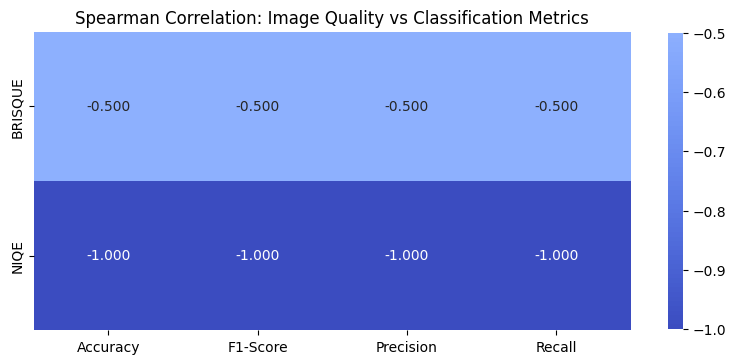

Interpretation:
BRISQUE vs Accuracy: ρ = -0.500 (p=0.6667) - not significant
BRISQUE vs F1-Score: ρ = -0.500 (p=0.6667) - not significant
BRISQUE vs Precision: ρ = -0.500 (p=0.6667) - not significant
BRISQUE vs Recall: ρ = -0.500 (p=0.6667) - not significant
NIQE vs Accuracy: ρ = -1.000 (p=0.0000) - significant
NIQE vs F1-Score: ρ = -1.000 (p=0.0000) - significant
NIQE vs Precision: ρ = -1.000 (p=0.0000) - significant
NIQE vs Recall: ρ = -1.000 (p=0.0000) - significant


In [22]:
# This section was created with the help of Dominik Hampejs
# Section 13: Spearman Correlation between Quality and Classification Metrics

from scipy.stats import spearmanr

df_all = pd.DataFrame({
    'Dataset': ['Original', 'HE', 'CLAHE'],
    'NIQE': [niqe_orig.mean(), niqe_he.mean(), niqe_clahe.mean()],
    'BRISQUE': [brisque_orig.mean(), brisque_he.mean(), brisque_clahe.mean()],
    'Accuracy': [test_acc_orig, test_acc_he, test_acc_clahe],
    'Precision': [precision_orig, precision_he, precision_clahe],
    'Recall': [recall_orig, recall_he, recall_clahe],
    'F1-Score': [f1_orig, f1_he, f1_clahe]
})

print("\nCombined Dataset:")
print(df_all.round(4))

# List of IQA metrics (rows)
iqa_metrics = ['BRISQUE', 'NIQE']

# List of classification metrics (columns)
class_metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall']

# Create empty correlation matrix
correlation_matrix = pd.DataFrame(index=iqa_metrics, columns=class_metrics)
pvalue_matrix = pd.DataFrame(index=iqa_metrics, columns=class_metrics)

# Calculate each correlation
for iqa in iqa_metrics:
    for cls in class_metrics:
        # Get the two columns of data
        x = df_all[iqa].values
        y = df_all[cls].values
        
        # Calculate Spearman correlation
        corr, p_val = spearmanr(x, y)
        
        # Store results
        correlation_matrix.loc[iqa, cls] = corr
        pvalue_matrix.loc[iqa, cls] = p_val

# Convert to numeric
correlation_matrix = correlation_matrix.astype(float)
pvalue_matrix = pvalue_matrix.astype(float)

print("Spearnman Correaltion Matrix (ρ-values)")
print(correlation_matrix.round(4))

print("p-values (significance)")
print(pvalue_matrix.round(4))

# Simple heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', square=True, cbar_kws={'shrink': 0.8})
plt.title('Spearman Correlation: Image Quality vs Classification Metrics', fontsize=12)
plt.tight_layout()
plt.show()

print("Interpretation:")
for iqa in iqa_metrics:
    for cls in class_metrics:
        corr = correlation_matrix.loc[iqa, cls]
        p_val = pvalue_matrix.loc[iqa, cls]
        if p_val < 0.05:
            sig = "significant"
        else:
            sig = "not significant"
        print(f"{iqa} vs {cls}: ρ = {corr:.3f} (p={p_val:.4f}) - {sig}")